# R4 Bus Delays at UBC: Step-by-Step Analysis

**Question:** How reliable is the TransLink R4 when it departs UBC Exchange (Bay 4)?

**Data:** Live GTFS-Realtime updates collected every 60 seconds by a script running on Railway, saved as `r4_ubc_live_log.csv`.

Run the cells in order with **Shift+Enter**. Put the CSV in the same folder as this notebook.

## Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("r4_ubc_live_log.csv")
print(df.shape)
df.head()

(2476, 7)


,collected_at,trip_id,route_id,stop_id,direction,arrival_delay_sec,departure_delay_sec
0,2026-09-18T17:06:47.311740+00:00,15509049,37810,12361,departing_UBC,0.0,0.0
1,2026-09-18T17:07:48.021986+00:00,15509049,37810,12361,departing_UBC,0.0,0.0
2,2026-09-18T17:20:57.540774+00:00,15509051,37810,12361,departing_UBC,0.0,0.0
3,2026-09-18T17:21:58.234228+00:00,15509051,37810,12361,departing_UBC,0.0,0.0
4,2026-09-18T18:08:33.328110+00:00,15509055,37810,12361,departing_UBC,1210.0,1210.0


Each row is **one poll of the live feed**, not one bus. A bus sitting near the stop gets logged every minute until it leaves.

## Check data quality before analyzing

In [2]:
df["collected_at"] = pd.to_datetime(df["collected_at"], utc=True)

print("Date range:", df["collected_at"].min(), "to", df["collected_at"].max())
print()
print("Rows per direction:")
print(df["direction"].value_counts())
print()
print("Rows with a blank delay value:", df["arrival_delay_sec"].isna().sum(), "of", len(df))
print("Duplicate rows:", df.duplicated().sum())

Date range: 2026-09-18 17:06:47.311740+00:00 to 2026-09-28 17:38:06.655421+00:00

Rows per direction:
direction
departing_UBC    2476
Name: count, dtype: int64

Rows with a blank delay value: 1070 of 2476
Duplicate rows: 0


Two things to note:
- Only `departing_UBC` appears. The arriving stop (Unloading Only) is in the *schedule* but TransLink's live feed never reports it, so this analysis covers **departures only**.
- Many rows have a blank delay. The feed knew a trip existed but had not attached timing yet. Those rows carry no delay information, so we drop them.

## Clean the data

The timestamps are in UTC. Convert to Vancouver time so that "hour" and "weekday" match what riders experience.

In [3]:
df = df.dropna(subset=["arrival_delay_sec"]).copy()
df["arrival_delay_sec"] = df["arrival_delay_sec"].astype(int)
df["delay_min"] = df["arrival_delay_sec"] / 60
df["collected_at"] = df["collected_at"].dt.tz_convert("America/Vancouver")

print(len(df), "rows with delay data")
df.head()

1406 rows with delay data


,collected_at,trip_id,route_id,stop_id,direction,arrival_delay_sec,departure_delay_sec,delay_min
0,2026-09-18 10:06:47.311740-07:00,15509049,37810,12361,departing_UBC,0,0.0,0.000000
1,2026-09-18 10:07:48.021986-07:00,15509049,37810,12361,departing_UBC,0,0.0,0.000000
2,2026-09-18 10:20:57.540774-07:00,15509051,37810,12361,departing_UBC,0,0.0,0.000000
3,2026-09-18 10:21:58.234228-07:00,15509051,37810,12361,departing_UBC,0,0.0,0.000000
4,2026-09-18 11:08:33.328110-07:00,15509055,37810,12361,departing_UBC,1210,1210.0,20.166667


## One row per bus run

`trip_id` is a *scheduled* trip, and the **same trip_id runs every day**. So we can't group by `trip_id` alone or different days get merged together. Instead, a new "run" starts whenever a trip_id reappears after a gap of more than 3 hours.

For each run we keep its **last** delay reading: it is closest to the actual departure, and early predictions in this feed are sometimes off by 10-30 minutes before correcting themselves.

In [4]:
df = df.sort_values(["trip_id", "collected_at"])
gap = df.groupby("trip_id")["collected_at"].diff()
new_run = gap.isna() | (gap > pd.Timedelta(hours=3))
df["run_id"] = new_run.cumsum()

runs = df.sort_values("collected_at").groupby("run_id").last().reset_index()
runs["hour"] = runs["collected_at"].dt.hour
runs["weekday"] = runs["collected_at"].dt.day_name()

print(len(df), "polls collapsed into", len(runs), "bus runs")

1406 polls collapsed into 503 bus runs


## Overall reliability

We call a bus **on time** if it is within 5 minutes of schedule. That threshold is a common transit convention, and you can change it below.

In [5]:
ON_TIME_MIN = 5
runs["on_time"] = runs["delay_min"].abs() <= ON_TIME_MIN

print("Bus runs tracked:", len(runs))
print("Median delay (min):", round(runs["delay_min"].median(), 1))
print("Mean delay (min):  ", round(runs["delay_min"].mean(), 1))
print(f"On-time rate (within {ON_TIME_MIN} min): {runs['on_time'].mean() * 100:.1f}%")
print("Runs more than 10 min late:", (runs["delay_min"] > 10).sum())

Bus runs tracked: 503
Median delay (min): 0.0
Mean delay (min):   0.6
On-time rate (within 5 min): 96.8%
Runs more than 10 min late: 6


## Delay distribution

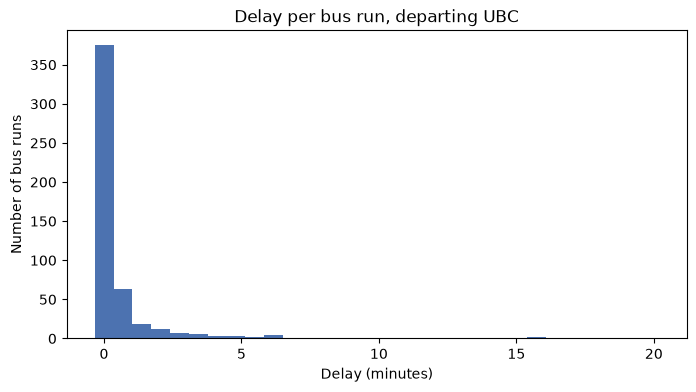

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(runs["delay_min"], bins=30, color="#4C72B0")
plt.title("Delay per bus run, departing UBC")
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of bus runs")
plt.show()

Most buses cluster at zero, with a long thin tail of late buses.

## Delay by hour of day (Vancouver time)

,mean,median,count
hour,,,
0,2.0,1.7,40
1,0.7,0.3,10
5,0.4,0.2,24
6,1.1,0.5,54
7,0.1,0.0,22
8,0.1,0.0,22
9,0.1,0.0,13
10,0.4,0.0,24
11,1.7,0.0,13


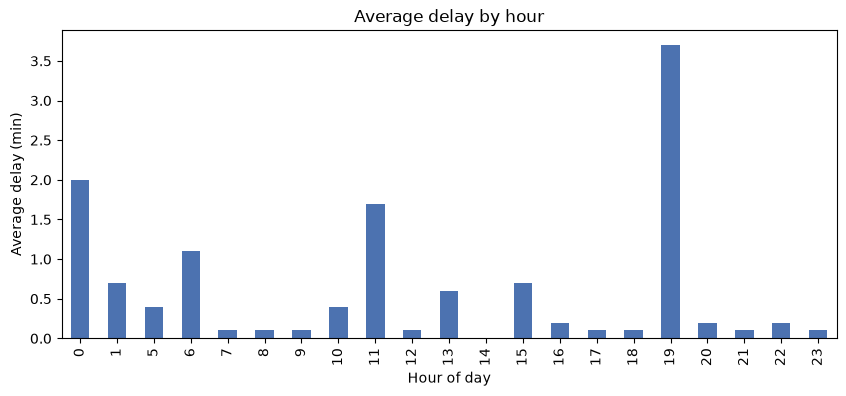

In [11]:
by_hour = runs.groupby("hour")["delay_min"].agg(["mean", "median", "count"]).round(1)
display(by_hour)

by_hour["mean"].plot(kind="bar", figsize=(10, 4), color="#4C72B0")
plt.title("Average delay by hour")
plt.xlabel("Hour of day")
plt.ylabel("Average delay (min)")
plt.show()

Check the `count` column before trusting a tall bar. An hour with 16 runs can be swung by two very late buses.

## Delay by weekday

,mean_delay,on_time_rate,runs
weekday,,,
Monday,0.42,0.99,115
Tuesday,0.61,0.98,54
Wednesday,0.64,0.95,60
Thursday,0.67,0.96,68
Friday,0.64,0.97,86
Saturday,0.52,0.98,66
Sunday,1.21,0.93,54


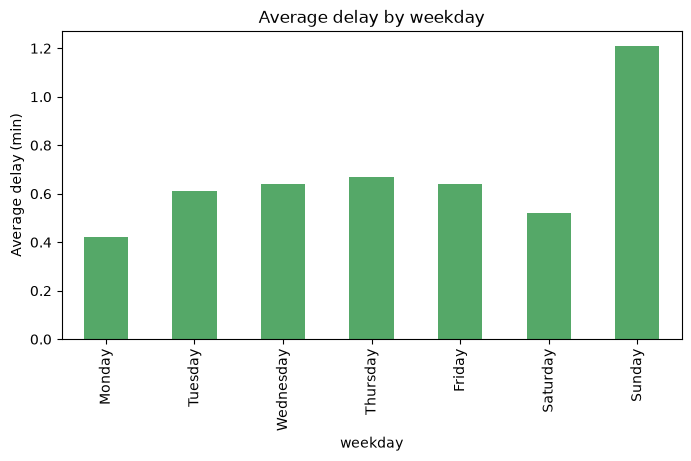

In [12]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = runs.groupby("weekday").agg(
    mean_delay=("delay_min", "mean"),
    on_time_rate=("on_time", "mean"),
    runs=("delay_min", "count"),
).reindex(order).round(2)
display(by_day)

by_day["mean_delay"].plot(kind="bar", figsize=(8, 4), color="#55A868")
plt.title("Average delay by weekday")
plt.ylabel("Average delay (min)")
plt.show()

## The biggest delays

Look at extreme values individually, to judge whether they are real delays or feed glitches.

In [13]:
runs.sort_values("delay_min", ascending=False)[["collected_at", "trip_id", "delay_min"]].head(10)

,collected_at,trip_id,delay_min
30,2026-09-18 11:09:34.066617-07:00,15509055,20.166667
237,2026-09-24 19:34:34.850389-07:00,15509158,15.883333
471,2026-09-20 15:21:02.503627-07:00,15509699,15.633333
240,2026-09-25 19:44:04.049457-07:00,15509160,15.100000
56,2026-09-23 13:10:56.252126-07:00,15509072,14.300000
238,2026-09-22 19:43:35.700315-07:00,15509160,13.033333
352,2026-09-24 15:54:27.277627-07:00,15509204,8.316667
495,2026-09-28 00:43:19.430608-07:00,15509740,7.383333
483,2026-09-20 19:48:08.140006-07:00,15509721,6.933333
302,2026-09-23 00:08:43.015946-07:00,15509183,6.366667


## Conclusions and limitations

**Conclusions**

Over the ten days collected (Sep 18–28, 2026), the R4 was reliable departing UBC Exchange (Bay 4): 96.8% of the 503 tracked runs left within 5 minutes of schedule, and the median delay was 0 minutes. Only 6 runs were more than 10 minutes late, with the worst around 20 minutes.

Sunday had the lowest on-time rate of any day (92.6%, 1.2 min average delay), while Monday had the highest (99.1%). The data doesn't say why as it could be traffic, ridership, driver scheduling, or something else so I'm reporting the number without assuming a cause. 7pm showed the worst hourly average (69% on time), but that's based on just 16 runs and driven by two delayed buses, so I'd treat it as something to watch in future weeks rather than a real pattern yet.

The data will continue to be collected to make the analysis more statistically reliable as more weeks accumulate.

**Limitations**

- **Partial coverage**: the feed didn't return a delay reading for every scheduled trip, so this covers roughly 50 runs a day, not every bus.
- **One direction only**: the arrival stop (Unloading Only, stop 12600) never appeared in ten days of live polling, so nothing here says anything about buses arriving at UBC.
- **Small per-hour samples**: most hours have 10–60 runs behind them — enough to see the broad on-time rate, not enough to trust any single hour.
- **Ten days**: long enough for a baseline, too short to know if the weekday and hourly patterns hold up over time.